<a href="https://colab.research.google.com/github/kyforstudy/kaggle-solutions/blob/gh-pages/CNN_LSTM_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Libraries

In [ ]:
import os
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from collections import Counter
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D, Conv1D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup

## Visualizations

In [ ]:
# Downloads
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')

# Load data
df = pd.read_csv('/content/drive/MyDrive/DSA5207/data/labeled_data.csv')
df = df.dropna(subset=['review', 'label']).reset_index(drop=True)

# Map numerical labels to text labels
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
df['label_name'] = df['label'].map(label_map)

# Compute the number of words in each review
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

# Prepare stopword list
stop_words = set(stopwords.words('english'))
important_words = {'not', 'no', 'never'}
stop_words = stop_words - important_words

# Initialize the WordNet lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean and preprocess the input text by applying lowercasing, removing URLs, numbers,
    punctuation, and stopwords (excluding negation words). It also applies lemmatization.

    Parameters:
        text (str): The input text to clean.

    Returns:
        str: A cleaned version of the input text.
    """

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Apply text cleaning
df['clean_text'] = df['review'].apply(clean_text)

# Select and rename columns for saving
df_to_save = df[['clean_text', 'label']].rename(columns={'clean_text': 'text', 'label': 'sentiment'})
# df_to_save.to_csv('/content/drive/MyDrive/DSA5207/data/cleaned_data.csv', index=False) # Uncomment to save the file

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...


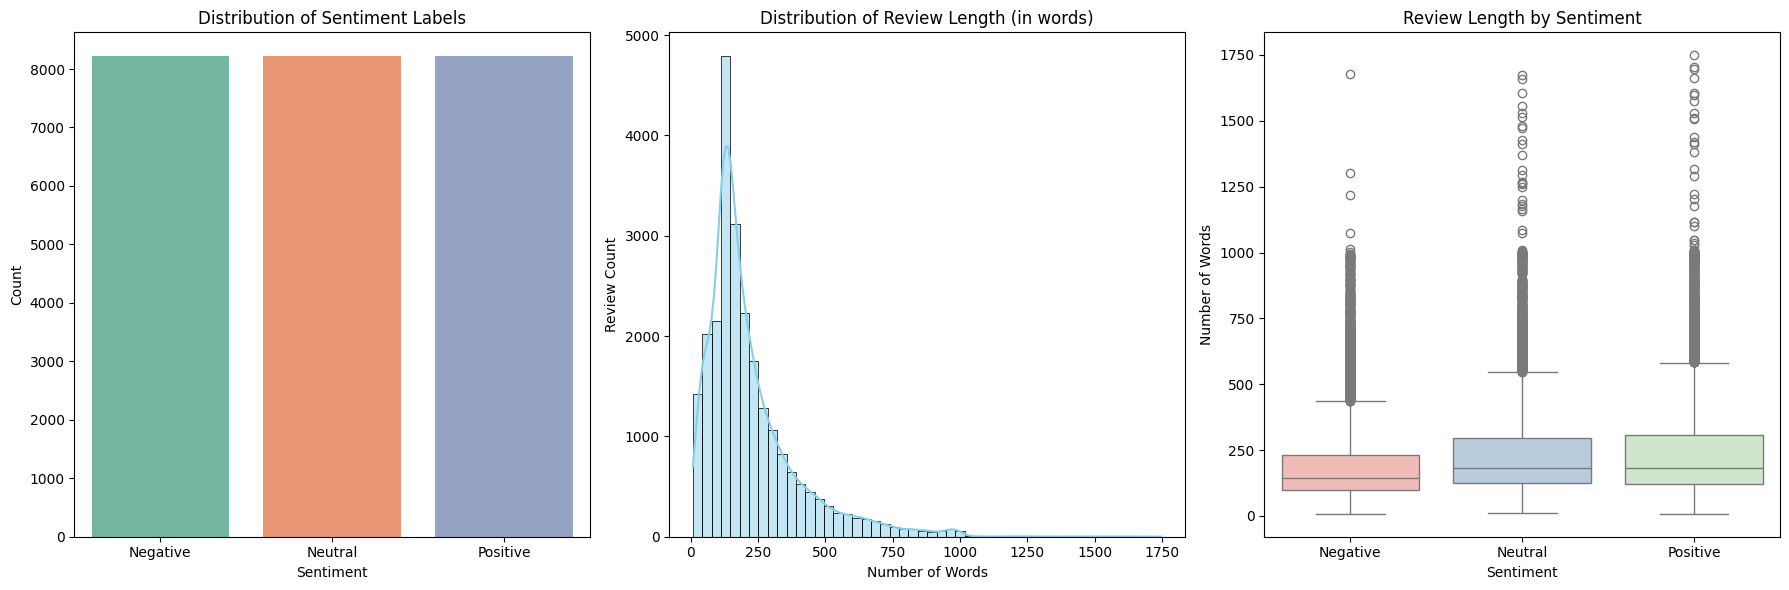

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Sentiment label distribution (bar chart)
sns.countplot(ax=axes[0], x='label_name', data=df, hue='label_name', palette='Set2')
axes[0].set_title("Distribution of Sentiment Labels")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].grid(False)

# Plot 2: Review length histogram
sns.histplot(ax=axes[1], data=df['review_length'], bins=50, kde=True, color='skyblue')
axes[1].set_title("Distribution of Review Length (in words)")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Review Count")
axes[1].grid(False)

# Plot 3: Boxplot of review length by sentiment
sns.boxplot(ax=axes[2], x='label_name', y='review_length', data=df, palette='Pastel1', hue='label_name')
axes[2].set_title("Review Length by Sentiment")
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("Number of Words")
axes[2].grid(False)

# Adjust spacing to prevent overlapping
plt.tight_layout()
plt.show()

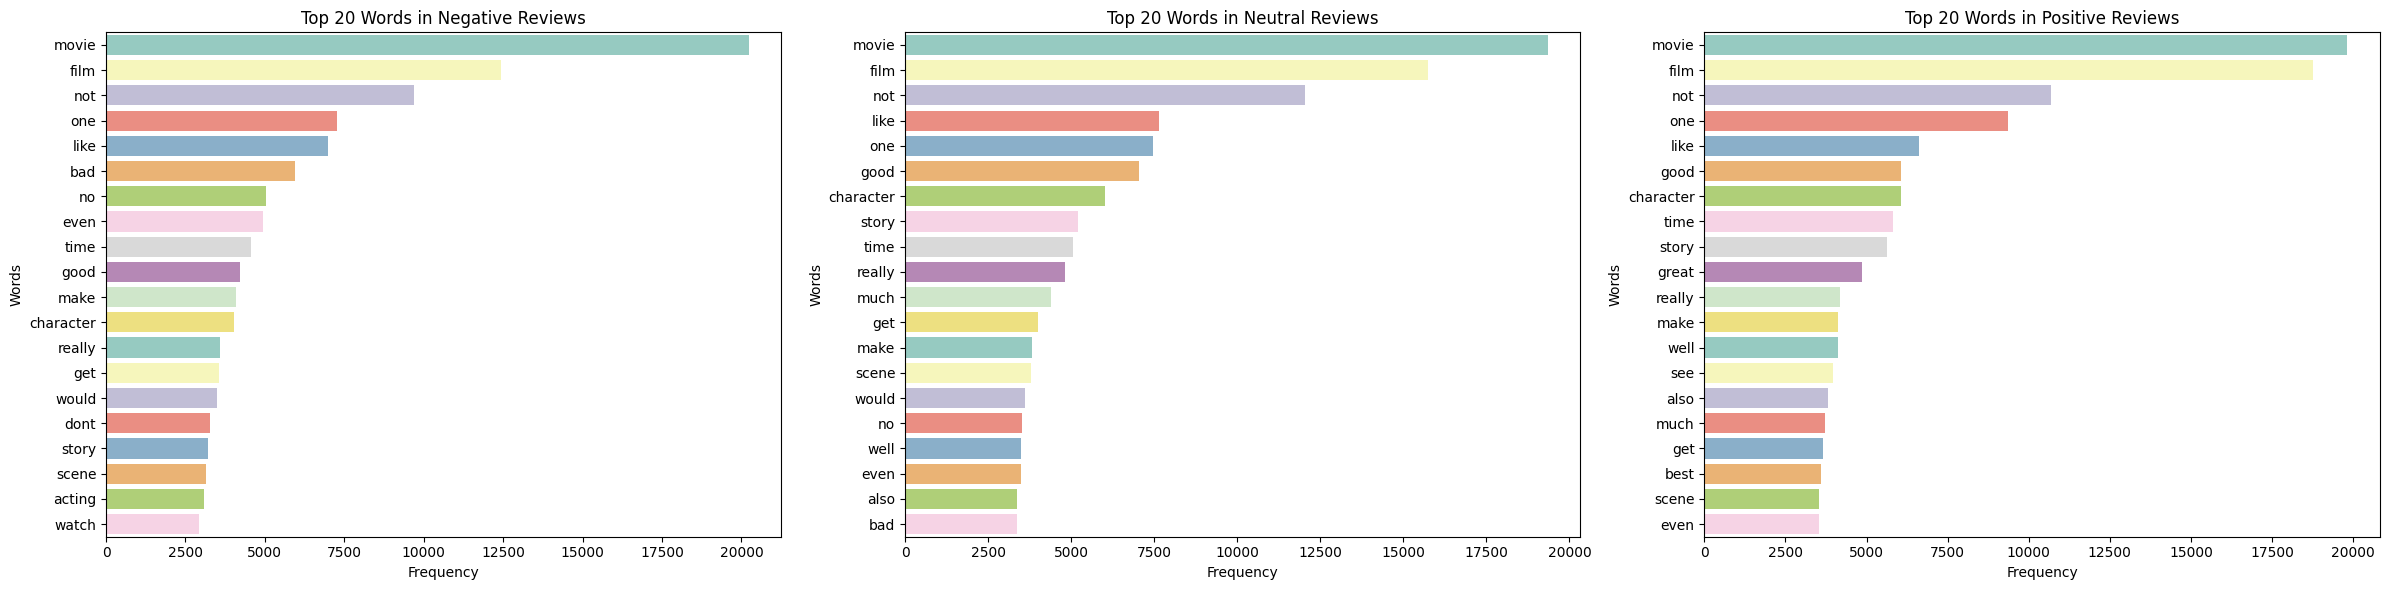

In [ ]:
# Function to get top N frequent words
def get_top_words(texts, n=20):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Loop through each sentiment label
for i, (label_num, label_str) in enumerate(label_map.items()):
    # Get top N frequent words
    top_words = get_top_words(df[df['label'] == label_num]['clean_text'])
    words, freqs = zip(*top_words)

    # Plot horizontal bar chart on the ith subplot
    sns.barplot(x=list(freqs), y=list(words), hue=list(words),
                palette='Set3', legend=False, ax=axes[i])

    axes[i].set_title(f"Top {len(words)} Words in {label_str} Reviews")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("Words")
    axes[i].grid(False)

# Adjust layout
plt.tight_layout()
plt.show()

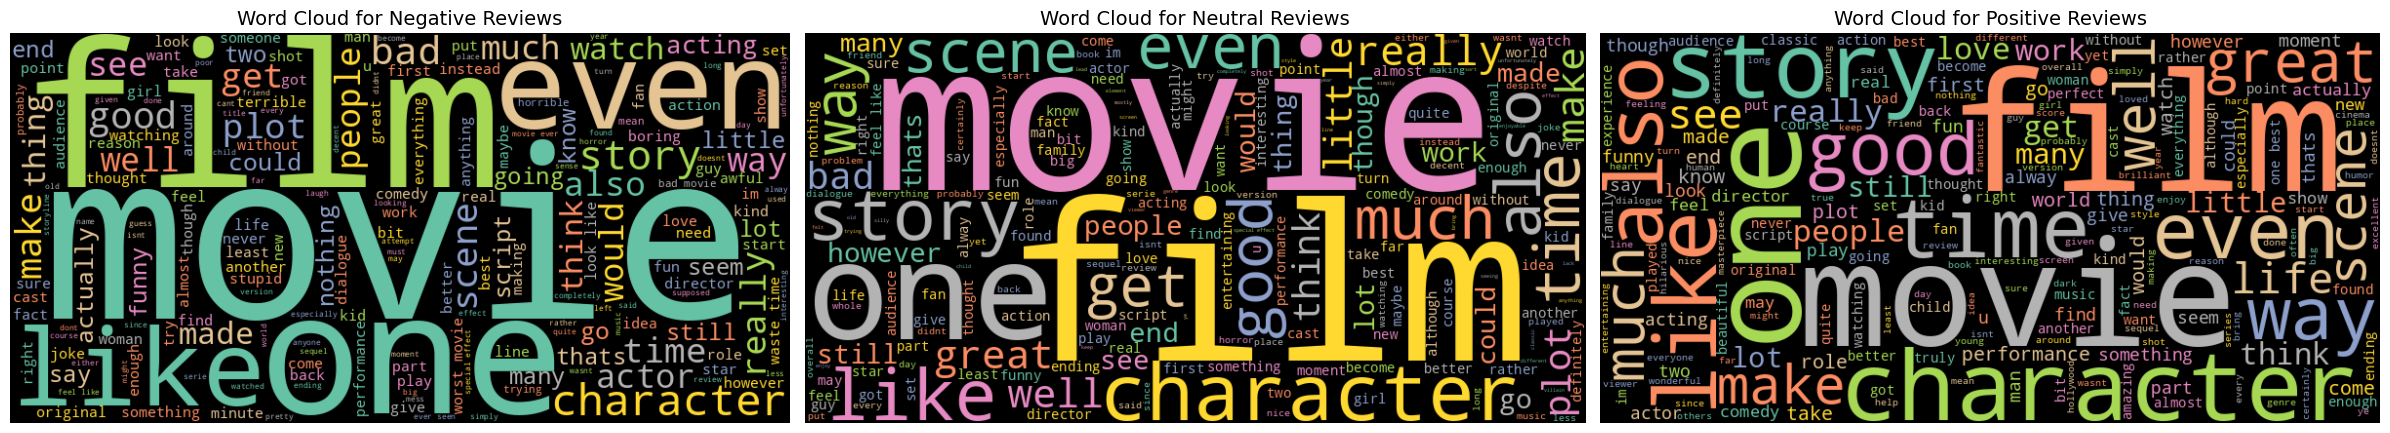

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Loop through each label to generate word cloud
for i, (label_num, label_str) in enumerate(label_map.items()):
    # Combine all text for this sentiment label
    text_data = " ".join(df[df['label'] == label_num]['clean_text'])

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='black',
                          stopwords=set(stopwords.words('english')),
                          max_words=200, colormap='Set2').generate(text_data)

    # Display in subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud for {label_str} Reviews", fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

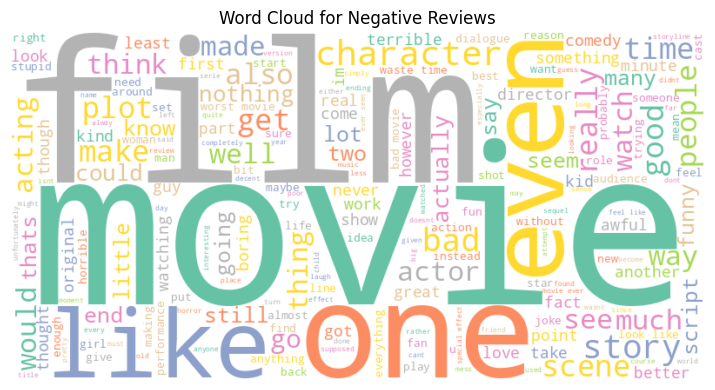

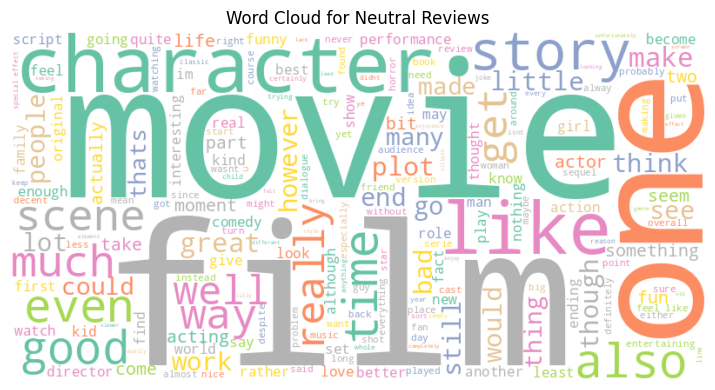

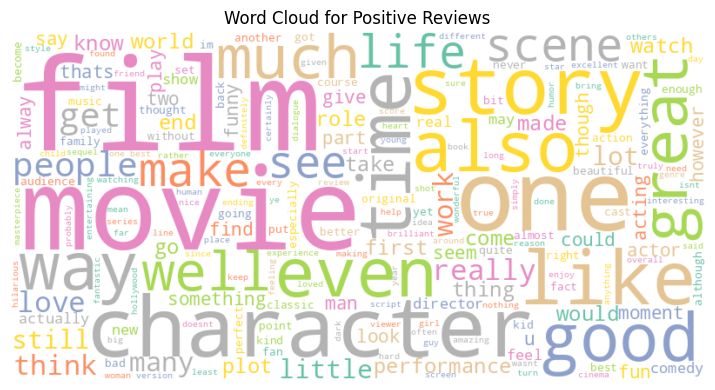

In [ ]:
# Word clouds with white background
for label_num, label_str in label_map.items():
    text_data = " ".join(df[df['label'] == label_num]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          stopwords=set(stopwords.words('english')),
                          max_words=200, colormap='Set2').generate(text_data)
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {label_str} Reviews")
    plt.tight_layout()
    plt.show()

#### SentimentIntensityAnalyzer
SentimentIntensityAnalyzer is a tool from the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis model. It is designed specifically for social media texts and informal language (like tweets, reviews, comments) and performs particularly well on short texts.

It calculates the intensity of sentiments and returns a dictionary with four key sentiment scores:

* neg: Probability of negative sentiment (range: 0–1)

* neu: Probability of neutral sentiment (range: 0–1)

* pos: Probability of positive sentiment (range: 0–1)

* compound: A normalized, weighted composite score from -1 (most negative) to +1 (most positive)

In [ ]:
# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment polarity
def get_polarity(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)
    else:
        return None

# Apply sentiment polarity function to the 'clean_text' column
df["Polarity"] = df["clean_text"].apply(get_polarity)

# Split polarity into separate columns
df["Negative"] = df["Polarity"].apply(lambda x: x['neg'] if isinstance(x, dict) else None)
df["Neutral"] = df["Polarity"].apply(lambda x: x['neu'] if isinstance(x, dict) else None)
df["Positive"] = df["Polarity"].apply(lambda x: x['pos'] if isinstance(x, dict) else None)

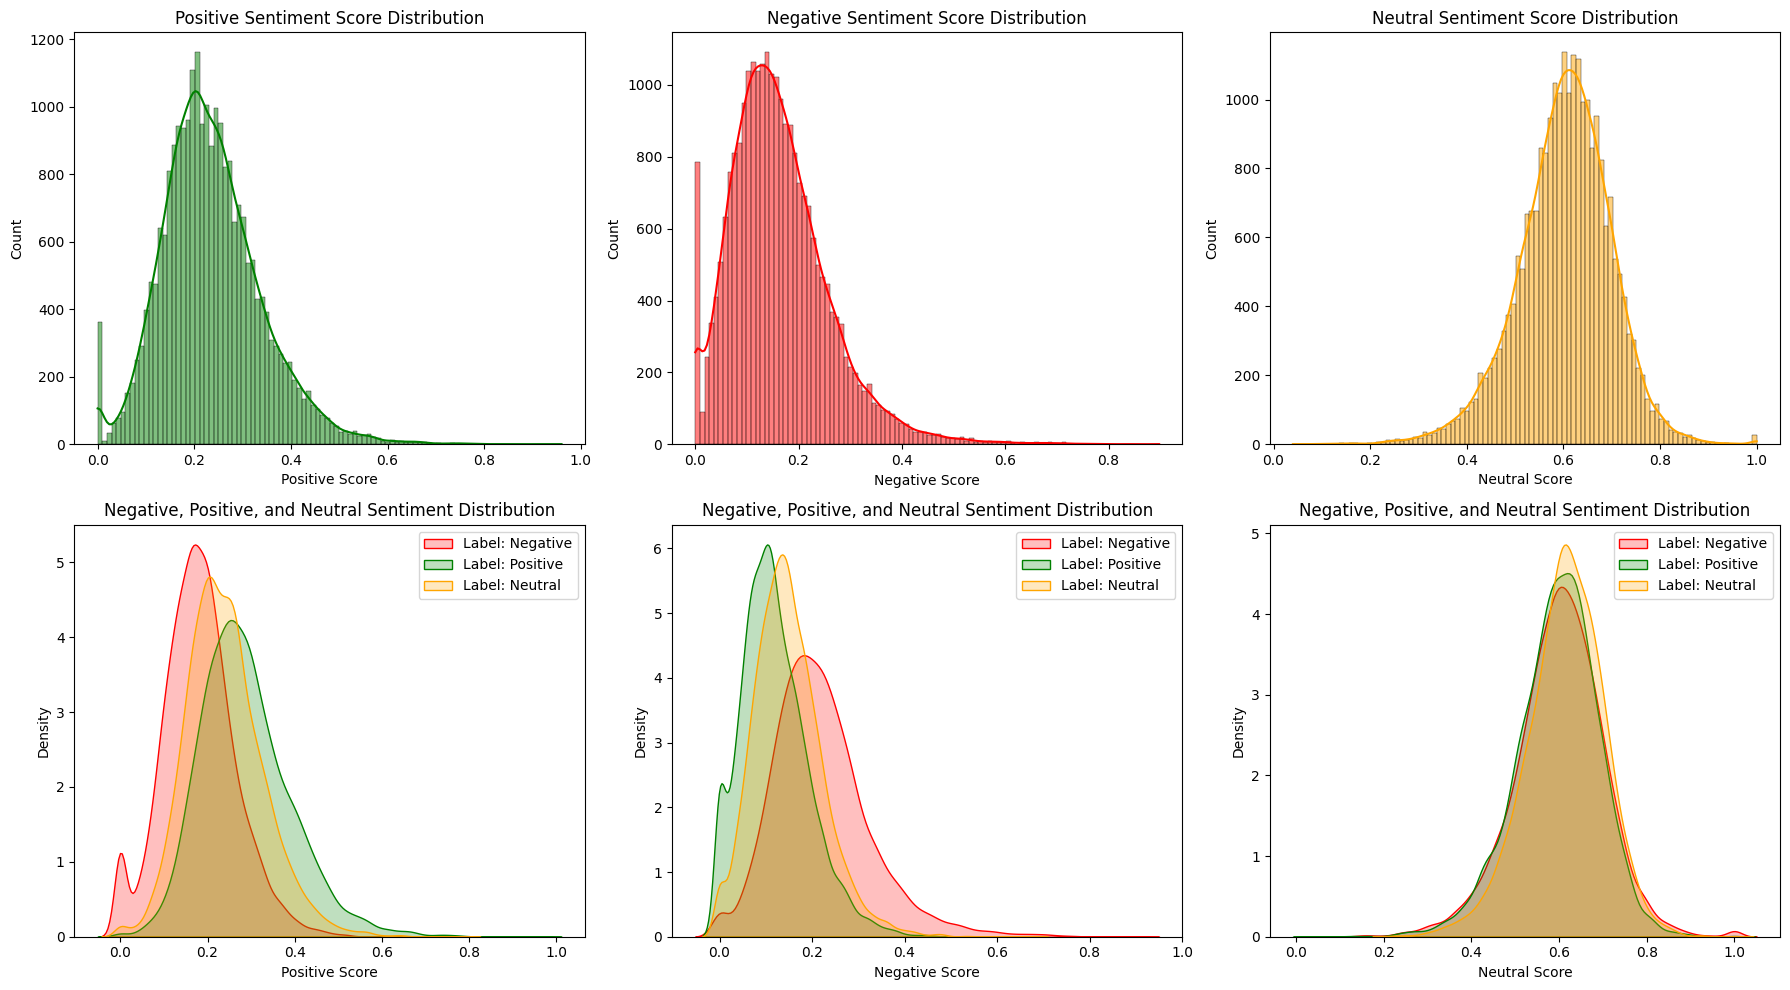

In [ ]:
# Function to plot histogram with KDE(Kernel Density Estimate)
def plot_histogram(ax, data, column, bins=100, color='blue', title=None, xlabel=None, ylabel=None):
    sns.histplot(data[column].dropna(), bins=bins, color=color, kde=True, ax=ax)

    if title is None:
        title = f"{column} Sentiment Score Distribution"
    if xlabel is None:
        xlabel = f"{column} Score"
    if ylabel is None:
        ylabel = "Count"

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)

# Function to plot KDE for three categories
def plot_kde(ax, data, column, label_col='label_name', label1='Negative', label2='Positive', label3='Neutral',
             color1='red', color2='green', color3='orange', title=None, xlabel=None, ylabel=None):
    sns.kdeplot(data=data[data[label_col] == label1][column].dropna(), label=f'Label: {label1}', color=color1, fill=True, ax=ax)
    sns.kdeplot(data=data[data[label_col] == label2][column].dropna(), label=f'Label: {label2}', color=color2, fill=True, ax=ax)
    sns.kdeplot(data=data[data[label_col] == label3][column].dropna(), label=f'Label: {label3}', color=color3, fill=True, ax=ax)

    if title is None:
        title = f"{label1}, {label2}, and {label3} Sentiment Distribution"
    if xlabel is None:
        xlabel = f"{column} Score"
    if ylabel is None:
        ylabel = "Density"

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(False)

# Create a 2x3 grid for the plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot histograms in the first row
plot_histogram(axes[0, 1], df, "Negative", color='red')
plot_histogram(axes[0, 2], df, "Neutral", color='orange')
plot_histogram(axes[0, 0], df, "Positive", color='green')

# Plot KDEs in the second row
plot_kde(axes[1, 1], df, "Negative")
plot_kde(axes[1, 2], df, "Neutral")
plot_kde(axes[1, 0], df, "Positive")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Data Augmentation

In [ ]:
# Load the cleaned dataset
data = pd.read_csv('/content/drive/MyDrive/DSA5207/data/cleaned_data.csv')
texts = data['text'].values
labels = data['sentiment'].values

# WordNet neutral enhancements
nltk.download('wordnet')
nltk.download('omw-1.4')

def synonym_augmentation(text):
    """
    Replace words in the input text with their synonyms using WordNet.

    Parameters:
        text (str): The input sentence.

    Returns:
        str: The sentence with some words replaced by their synonyms.
    """

    words = text.split()
    augmented_text = []
    for word in words:
        synsets = wordnet.synsets(word)
        if synsets:
            synonym = random.choice(synsets).lemmas()[0].name()
            if synonym != word:
                augmented_text.append(synonym)
            else:
                augmented_text.append(word)
        else:
            augmented_text.append(word)
    return ' '.join(augmented_text)

def augment_neutral_data(texts, labels):
    """
    Apply synonym augmentation to only the neutral class data (label == 1).

    Parameters:
        texts (array-like): List of input texts.
        labels (array-like): List of sentiment labels.

    Returns:
        tuple: A tuple containing the augmented texts and corresponding labels.
    """

    augmented_texts = []
    augmented_labels = []
    for i, label in enumerate(labels):
        if label == 1:
            augmented_texts.append(synonym_augmentation(texts[i]))
            augmented_labels.append(label)
        else:
            augmented_texts.append(texts[i])
            augmented_labels.append(label)
    return augmented_texts, augmented_labels

# Apply the augmentation process
augmented_texts, augmented_labels = augment_neutral_data(texts, labels)

# Save the augmented data to a CSV file
augmented_data = pd.DataFrame({'text': augmented_texts, 'sentiment': augmented_labels})
# augmented_data.to_csv('/content/drive/MyDrive/DSA5207/data/augmented_data.csv', index=False) # Uncomment to save the file

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## Data Preprocessing

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DSA5207/data/augmented_data.csv')

In [ ]:
# Stratified split: Train (64%), Validation (16%), Test (20%)
train_val_data, test_data = train_test_split(
    data, test_size=0.2, stratify=data['sentiment'], random_state=42
)
train_data, val_data = train_test_split(
    train_val_data, test_size=0.2, stratify=train_val_data['sentiment'], random_state=42
)

# Build vocabulary using Keras Tokenizer (limit to 5000 words)
token = Tokenizer(num_words=5000, lower=False, oov_token="<OOV>")
token.fit_on_texts(train_data['text'])

# Convert texts to sequences
x_train = token.texts_to_sequences(train_data['text'])
x_val = token.texts_to_sequences(val_data['text'])
x_test = token.texts_to_sequences(test_data['text'])

# Compute average sequence length for padding
def get_avg_length(x_data):
    lengths = [len(seq) for seq in x_data]
    return int(np.ceil(np.mean(lengths)))

avg_length = get_avg_length(x_train)
print("Average sequence length (rounded up):", avg_length)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=avg_length, padding='post', truncating='post')
x_val = pad_sequences(x_val, maxlen=avg_length, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=avg_length, padding='post', truncating='post')

# Prepare labels (use the 'sentiment' column directly)
y_train = np.array(train_data['sentiment'])
y_val = np.array(val_data['sentiment'])
y_test = np.array(test_data['sentiment'])

# Get total vocabulary size (including OOV and padding)
total_words = min(5000, len(token.word_index)) + 1
print(f"Vocabulary size (including <OOV> and padding): {total_words}")

Average sequence length (rounded up): 121
Vocabulary size (including <OOV> and padding): 5001


In [ ]:
# GloVe word vector dimensions
EMBEDDING_DIM = 100

# Load GloVe word vectors
embeddings_index = {}
with open('/content/drive/MyDrive/DSA5207/glove.6B/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Construct the embedding matrix
embedding_matrix = np.zeros((total_words, EMBEDDING_DIM))
for word, i in token.word_index.items():
    if i < total_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

## Modeling

#### Training and Evaluation Function

In [ ]:
def compile_and_train_model(
    model, x_train, y_train, x_val, y_val, x_test, y_test, checkpoint_path,
    epochs=20, batch_size=64, learning_rate=1e-3, patience=3,
    use_reduce_lr=True, reduce_lr_patience=2, class_weights=None
):
    """
    Compile and train the model, evaluate on the test set.

    Parameters:
    - model: Keras model to train (e.g., LSTM or CNN)
    - x_train, y_train: training data and labels
    - x_val, y_val: validation data and labels
    - x_test, y_test: test data and labels
    - checkpoint_path: path to save the best model
    - epochs: number of training epochs
    - batch_size: batch size for training
    - learning_rate: initial learning rate
    - patience: EarlyStopping patience
    - use_reduce_lr: whether to use ReduceLROnPlateau
    - reduce_lr_patience: patience for ReduceLROnPlateau
    - class_weights: optional class weights, e.g., {0: 1.0, 1: 1.5, 2: 1.0}

    Returns:
    - history: training history object
    - test_loss, test_accuracy: evaluation results on test set
    """

    # Create directory to save the model
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    # Save the best model based on validation accuracy
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    )

    # Compile the model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    # Set training callbacks
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=reduce_lr_patience, min_lr=1e-5, verbose=1)

    callbacks = [early_stopping, checkpoint]
    if use_reduce_lr:
        callbacks.append(reduce_lr)

    # Train the model
    print("Training model with pretrained GloVe embeddings...")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights
    )

    # Evaluate the model on test data
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
    print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    return history, test_loss, test_accuracy

In [ ]:
def plot_training_history(history, model_name="Model"):
    """
    Plot training and validation accuracy and loss curves.

    Parameters:
    - history: Keras training history object
    - model_name: optional model name to use in the plot titles
    """
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot accuracy curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.legend()

    # Plot loss curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, x_train, y_train, x_test, y_test, model_name="Model", num_classes=3):
    """
    Evaluate the model with classification metrics and plots.

    Parameters:
    - model: trained Keras model
    - x_train, y_train: training data and labels
    - x_test, y_test: test data and labels
    - model_name: optional model name for plot titles
    - num_classes: number of output classes
    """
    print(f"\nEvaluating {model_name}")

    y_train_pred = np.argmax(model.predict(x_train), axis=1)
    y_test_pred = np.argmax(model.predict(x_test), axis=1)
    y_test_prob = model.predict(x_test)

    # Print classification reports
    print(f"\nTraining Set Performance for {model_name}:")
    print(classification_report(y_train, y_train_pred, digits=4))

    print(f"\nTest Set Performance for {model_name}:")
    print(classification_report(y_test, y_test_pred, digits=4))

    # Prepare ROC and radar plot data
    cm = confusion_matrix(y_test, y_test_pred)
    y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
        roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_test_prob[:, i])

    report = classification_report(y_test, y_test_pred, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    classes = [str(i) for i in range(num_classes)]
    df = pd.DataFrame({cls: [report[cls][m] for m in metrics] for cls in classes}, index=metrics)
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    # Generate plots: confusion matrix, ROC-AUC curve, radar chart
    fig = plt.figure(figsize=(18, 5))

    # Confusion matrix
    ax1 = fig.add_subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1)
    ax1.set_title(f"{model_name} - Confusion Matrix")
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")

    # ROC-AUC curve
    ax2 = fig.add_subplot(1, 3, 2)
    for i in range(num_classes):
        ax2.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_title(f"{model_name} - ROC-AUC Curve")
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.legend()

    # Radar chart
    ax3 = fig.add_subplot(1, 3, 3, polar=True)
    for cls in df.columns:
        values = df[cls].tolist() + [df[cls].tolist()[0]]
        ax3.plot(angles, values, label=f'Class {cls}', linewidth=2)
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics)
    ax3.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax3.set_yticklabels(["0.2", "0.4", "0.6", "0.8"])
    ax3.set_title(f"{model_name} - Radar Plot", size=14)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model_torch(model, test_loader, device, model_name="Model", num_classes=3):
    def collect_preds_and_probs(loader):
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        return np.array(all_labels), np.array(all_preds), np.array(all_probs)

    print(f"\nEvaluating {model_name} on Test Set:")
    y_true, y_pred, y_prob = collect_preds_and_probs(test_loader)

    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    y_bin = label_binarize(y_true, classes=list(range(num_classes)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc[i] = roc_auc_score(y_bin[:, i], y_prob[:, i])

    report = classification_report(y_true, y_pred, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    classes = [str(i) for i in range(num_classes)]
    df = pd.DataFrame({cls: [report[cls][m] for m in metrics] for cls in classes}, index=metrics)
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(18, 5))

    ax1 = fig.add_subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1)
    ax1.set_title(f"{model_name} - Confusion Matrix")
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")

    ax2 = fig.add_subplot(1, 3, 2)
    for i in range(num_classes):
        ax2.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_title(f"{model_name} - ROC-AUC")
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.legend()

    ax3 = fig.add_subplot(1, 3, 3, polar=True)
    for cls in df.columns:
        values = df[cls].tolist() + [df[cls].tolist()[0]]
        ax3.plot(angles, values, label=f'Class {cls}', linewidth=2)
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics)
    ax3.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax3.set_yticklabels(["0.2", "0.4", "0.6", "0.8"])
    ax3.set_title(f"{model_name} - Radar", size=14)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

#### LSTM

In [ ]:
# Define model directory and filename
model_save_dir = '/content/drive/MyDrive/DSA5207/model'
model_filename = 'lstm_model.keras'

# Path to save the LSTM model
checkpoint_path = os.path.join(model_save_dir, model_filename)

# Define BiLSTM model architecture
lstm_model = Sequential([
    Embedding(input_dim=total_words, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.001))  # 3-class classification
])

# Train the LSTM model using the utility function
lstm_history, test_loss, test_accuracy = compile_and_train_model(
    lstm_model, x_train, y_train, x_val, y_val, x_test, y_test,
    checkpoint_path=checkpoint_path,
    epochs=20,
    batch_size=64,
    learning_rate=1e-3,
    patience=3,
    reduce_lr_patience=2,
    class_weights={0: 1.0, 1: 1.5, 2: 1.0}
)

Training model with pretrained GloVe embeddings...
Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5303 - loss: 1.3547 - val_accuracy: 0.8413 - val_loss: 0.6819 - learning_rate: 0.0010
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8078 - loss: 0.7379 - val_accuracy: 0.8570 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8354 - loss: 0.6296 - val_accuracy: 0.8927 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8516 - loss: 0.5555 - val_accuracy: 0.8968 - val_loss: 0.4579 - learning_rate: 0.0010
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8610 - loss: 0.5153 - val_accuracy: 0.8971 - val_loss: 0.4375 - learning_rate: 0.0010
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8761 - loss: 0.4816 - val_accuracy: 0.8791 - val_loss: 0.4507 - learning_rate: 0.0010
Epoch 7/20
247/247 ━━━━━━━━━━━

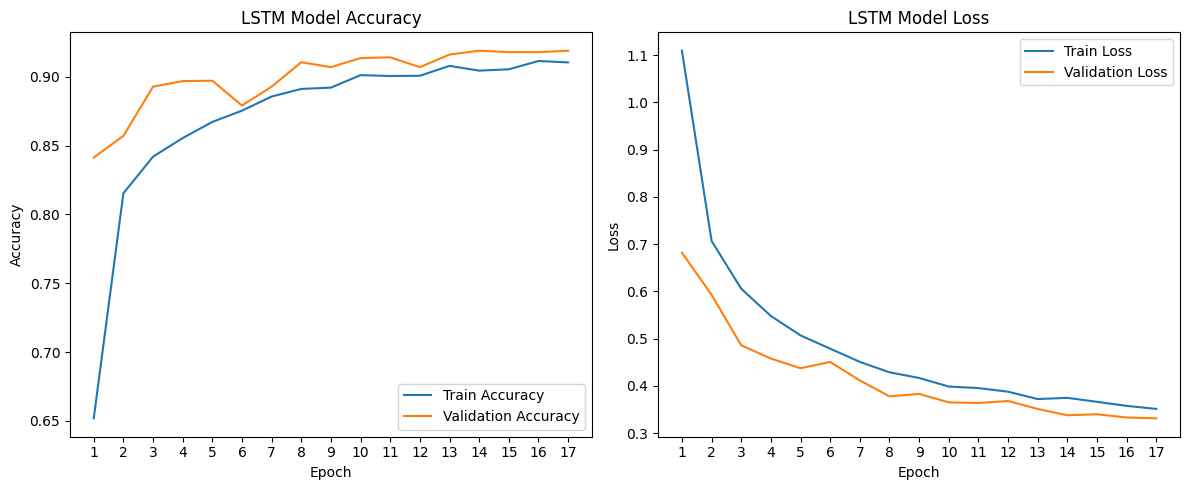

In [ ]:
plot_training_history(lstm_history, model_name="LSTM Model")


Evaluating LSTM Model
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Training Set Performance for LSTM Model:
              precision    recall  f1-score   support

           0     0.9027    0.9264    0.9144      5259
           1     0.9962    0.9937    0.9950      5258
           2     0.9236    0.9017    0.9125      5259

    accuracy                         0.9406     15776
   macro avg     0.9409    0.9406    0.9406     15776
weighted avg     0.9408    0.9406    0.9406     15776


Test Set Performance for LSTM Model:
              precision    recall  f1-score   support

           0     0.8680    0.9002    0.8838      1643
           1     0.9877    0.9799    0.9838      1644
           2     0.8935    0.8674    0.8802      1644

    accuracy                         0.9158      4931
   macro avg     0.9164    0.9158    0.9159      4931
weighted avg     0.9164    0.9158    0.9160      4931



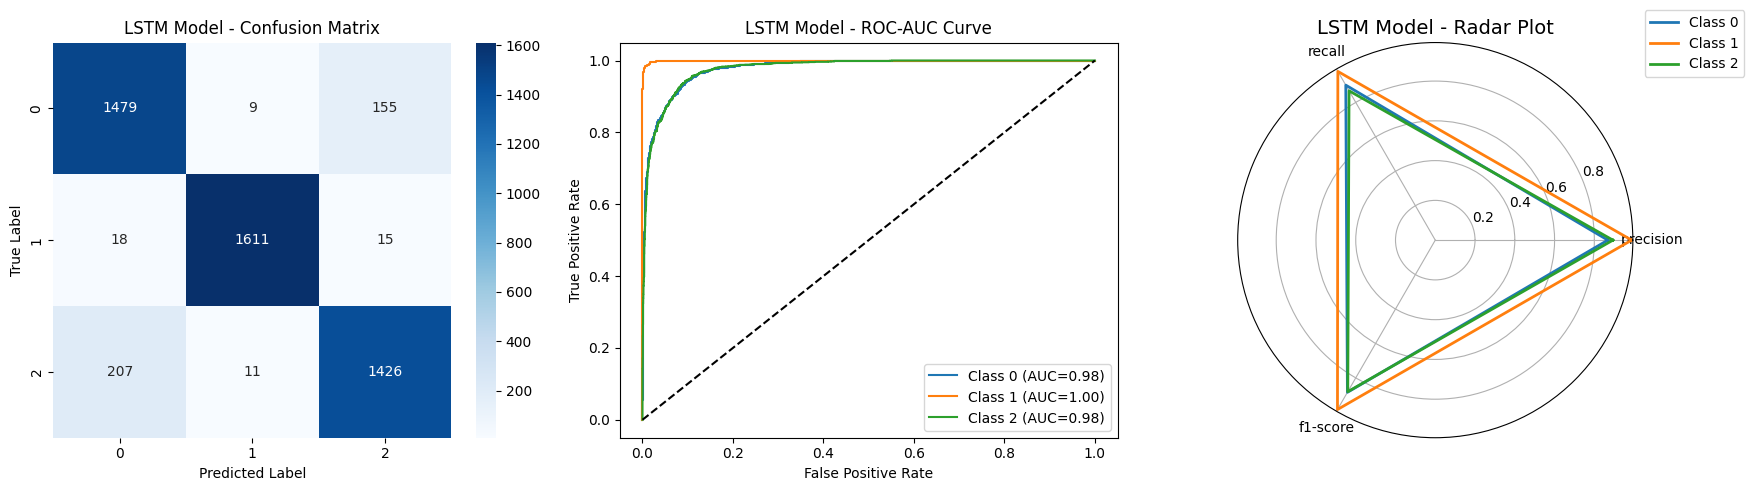

In [ ]:
evaluate_model(lstm_model, x_train, y_train, x_test, y_test, model_name="LSTM Model")

#### CNN

In [ ]:
# Define model directory and filename
model_save_dir = '/content/drive/MyDrive/DSA5207/model'
model_filename = 'cnn_model.keras'

# Path to save the CNN model
checkpoint_path = os.path.join(model_save_dir, model_filename)

# Define CNN model architecture
cnn_model = Sequential([
    Embedding(input_dim=total_words, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False),
    Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.001))  # 3-class classification
])

# Train the CNN model using the utility function
cnn_history, test_loss_cnn, test_accuracy_cnn = compile_and_train_model(
    cnn_model, x_train, y_train, x_val, y_val, x_test, y_test,
    checkpoint_path=checkpoint_path,
    epochs=20,
    batch_size=64,
    learning_rate=1e-3,
    patience=3,
    reduce_lr_patience=2,
    class_weights={0: 1.0, 1: 1.5, 2: 1.0}
)

Training model with pretrained GloVe embeddings...
Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4666 - loss: 1.8894 - val_accuracy: 0.5428 - val_loss: 0.9739 - learning_rate: 0.0010
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6736 - loss: 0.8046 - val_accuracy: 0.7860 - val_loss: 0.6165 - learning_rate: 0.0010
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7741 - loss: 0.6015 - val_accuracy: 0.8479 - val_loss: 0.4525 - learning_rate: 0.0010
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8213 - loss: 0.4876 - val_accuracy: 0.8588 - val_loss: 0.4060 - learning_rate: 0.0010
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8575 - loss: 0.4097 - val_accuracy: 0.8692 - val_loss: 0.3638 - learning_rate: 0.0010
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8714 - loss: 0.3728 - val_accuracy: 0.8753 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━

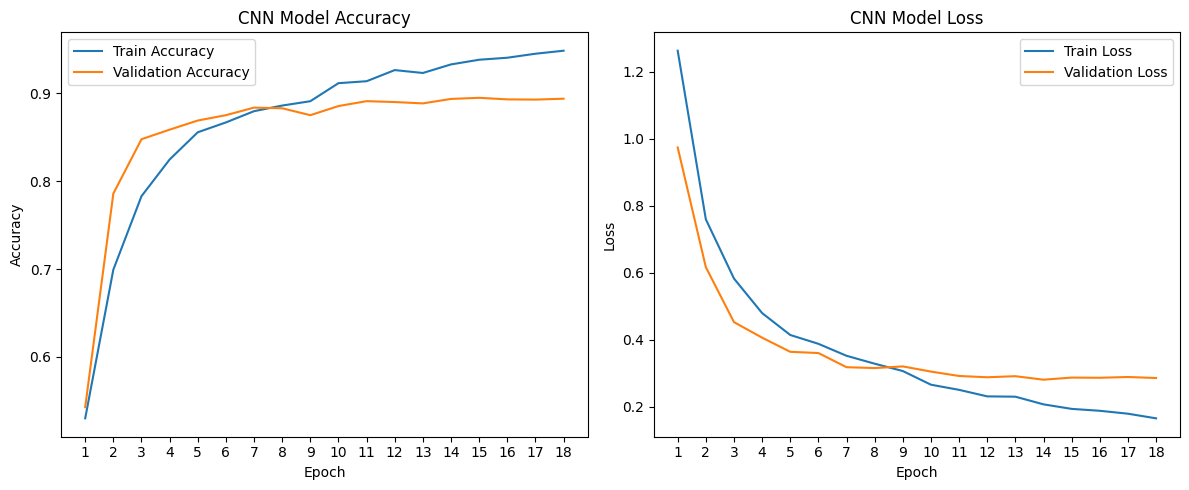

In [ ]:
plot_training_history(cnn_history, model_name="CNN Model")


Evaluating CNN Model
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Set Performance for CNN Model:
              precision    recall  f1-score   support

           0     0.9861    0.9551    0.9703      5259
           1     0.9972    0.9998    0.9985      5258
           2     0.9577    0.9852    0.9712      5259

    accuracy                         0.9800     15776
   macro avg     0.9803    0.9800    0.9800     15776
weighted avg     0.9803    0.9800    0.9800     15776


Test Set Performance for CNN Model:
              precision    recall  f1-score   support

           0     0.8733    0.8351    0.8538      1643
           1     0.9481    0.9787    0.9632      1644
           2     0.8557    0.8656    0.8606      1644

    accuracy                         0.8931      4931
   macro avg     0.8924    0.8931    0.8925      4931
weighted avg     0.8924    0.8931    0.8925      4931



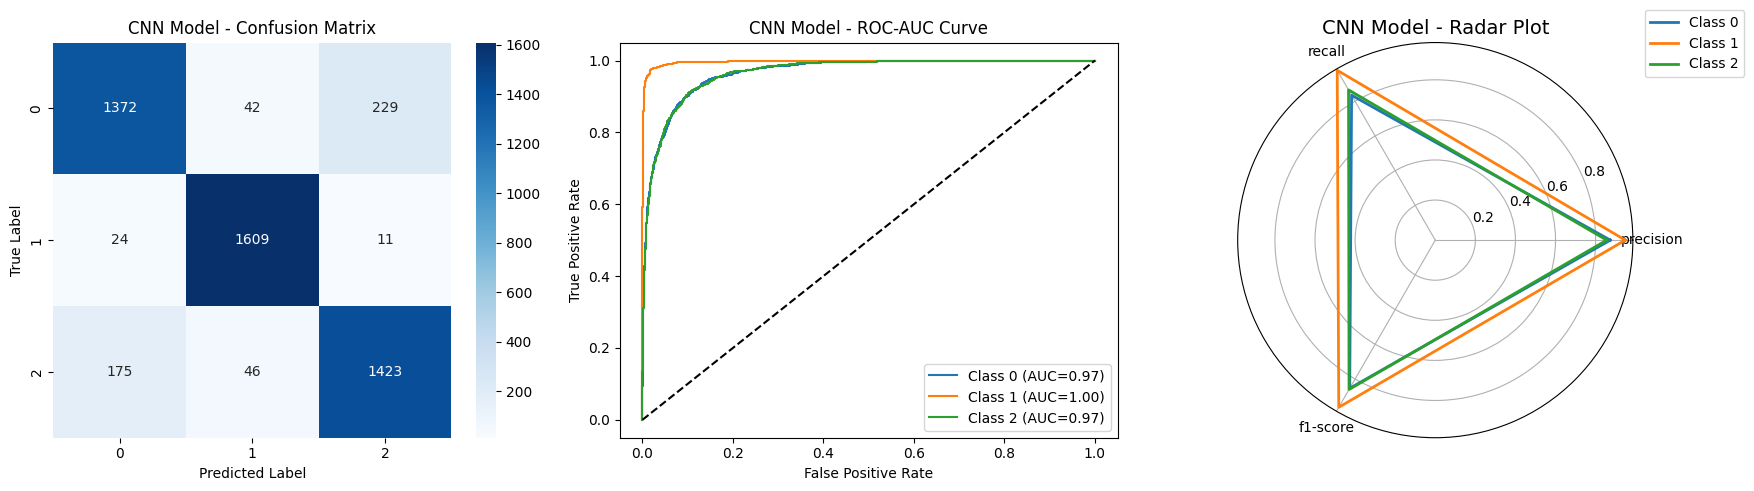

In [ ]:
evaluate_model(cnn_model, x_train, y_train, x_test, y_test, model_name="CNN Model")

#### RoBERTa

In [ ]:
# Basic configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
max_len = 96
num_workers = 2 if device.type == 'cuda' else 0

# Load the augmented dataset and split into training, validation, and test sets (64-16-20 ratio)
augmented_data = pd.read_csv('/content/drive/MyDrive/DSA5207/data/augmented_data.csv')
augmented_texts = augmented_data['text'].values
augmented_labels = augmented_data['sentiment'].values

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(augmented_texts, augmented_labels, test_size=0.2, random_state=42)
train_texts, val_texts, train_labels, val_labels = train_test_split(train_val_texts, train_val_labels, test_size=0.2, random_state=42)

# Initialize RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class ReviewDataset(Dataset):
    """
    Custom dataset for text classification using RoBERTa tokenizer.
    Applies dynamic padding during batching.
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_attention_mask=True
        )
        return {
            'input_ids': torch.tensor(encoding['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(encoding['attention_mask'], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def collate_fn(batch):
    """
    Custom collate function for dynamic padding in batches.
    """

    return {
        'input_ids': torch.nn.utils.rnn.pad_sequence(
            [item['input_ids'] for item in batch],
            batch_first=True
        ),
        'attention_mask': torch.nn.utils.rnn.pad_sequence(
            [item['attention_mask'] for item in batch],
            batch_first=True
        ),
        'label': torch.stack([item['label'] for item in batch])
    }

# Create DataLoaders
train_dataset = ReviewDataset(train_texts, train_labels, tokenizer, max_len)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer, max_len)
test_dataset = ReviewDataset(test_texts, test_labels, tokenizer, max_len)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size*2,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size*2,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=collate_fn
)

# Load pre-trained RoBERTa model with a classification head
bert_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)
bert_model.to(device)

# Training setup
epochs = 1
optimizer = AdamW(bert_model.parameters(), lr=5e-5)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)
scaler = GradScaler()  # For mixed precision training

def calculate_weights(labels):
    """
    Compute class weights to handle class imbalance.
    Assumes 3 classes: 0 (Negative), 1 (Neutral), 2 (Positive)
    """

    class_counts = np.bincount(labels)
    total_count = len(labels)
    weights = total_count / (3 * class_counts)
    return torch.tensor(weights, dtype=torch.float).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-5-074a63f1781a>:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


In [ ]:
# Training loop
for epoch in range(epochs):
    bert_model.train()
    optimizer.zero_grad()
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

    for batch in progress_bar:
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'labels': batch['label'].to(device)
        }

        # Apply class weights during loss computation
        weights = calculate_weights(inputs['labels'].cpu().numpy())
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        outputs = bert_model(**inputs)
        loss = loss_fct(outputs.logits, inputs['labels'])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step()

        progress_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{optimizer.param_groups[0]['lr']:.1e}"
        })

    # Validation evaluation
    print(f"\nValidation Epoch {epoch+1}:")
    bert_model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = bert_model(**inputs)
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())
    print(classification_report(true_labels, preds, target_names=['negative', 'neutral', 'positive']))

Epoch 1/1: 100%|██████████| 493/493 [04:35<00:00,  1.79it/s, loss=0.0836, lr=0.0e+00]



Validation Epoch 1:


Evaluating: 100%|██████████| 62/62 [00:22<00:00,  2.72it/s]

              precision    recall  f1-score   support

    negative       0.93      0.90      0.92      1316
     neutral       1.00      0.99      0.99      1287
    positive       0.90      0.94      0.92      1341

    accuracy                           0.94      3944
   macro avg       0.94      0.94      0.94      3944
weighted avg       0.94      0.94      0.94      3944




Evaluating RoBERTa Model on Test Set:
              precision    recall  f1-score   support

           0     0.9243    0.9111    0.9177      1676
           1     0.9981    0.9759    0.9869      1621
           2     0.9026    0.9357    0.9189      1634

    accuracy                         0.9406      4931
   macro avg     0.9417    0.9409    0.9411      4931
weighted avg     0.9414    0.9406    0.9408      4931



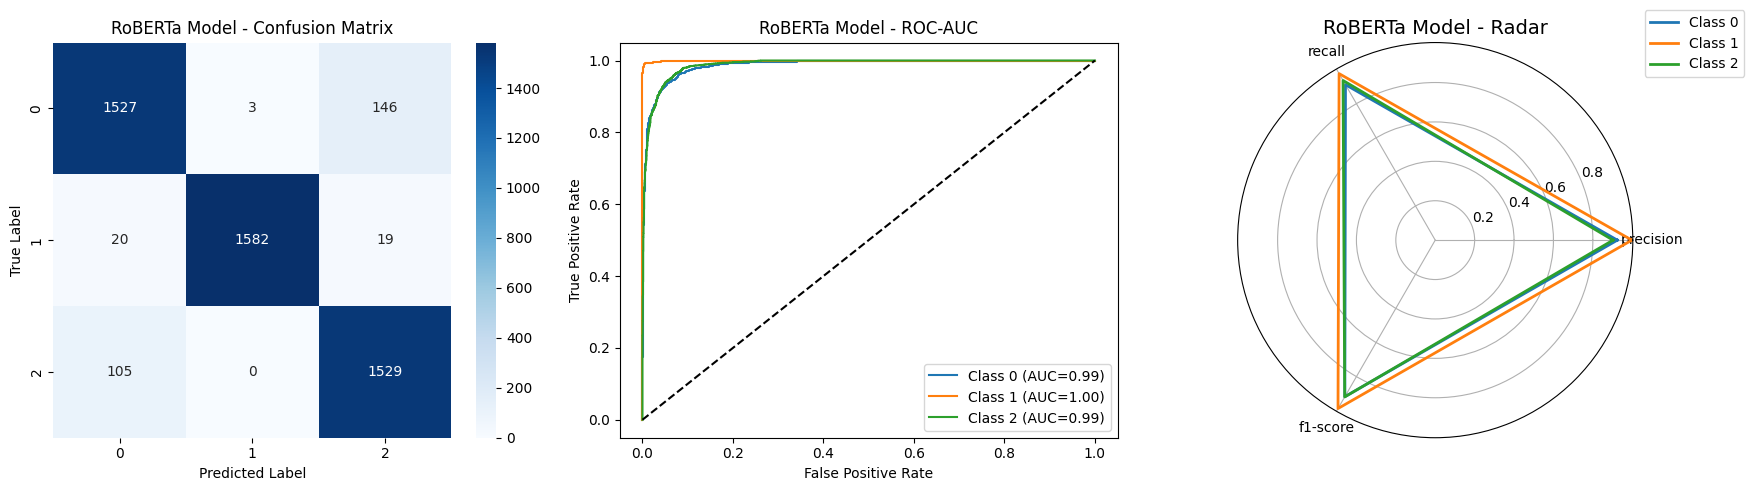

In [ ]:
evaluate_model_torch(
    model=bert_model,
    test_loader=test_loader,
    device=device,
    model_name="RoBERTa Model",
    num_classes=3
)